# 29회차 기출문제


## 문제 1

**Data description**

임대아파트 입주자 퇴거여부 예측을 위한 데이터입니다.

-   **순번**: 데이터의 순서를 나타내는 고유 번호
-   **계약구분**: 계약의 유형(예: 유효, 해지)
-   **재계약횟수**: 재계약이 이루어진 횟수
-   **거주개월**: 해당 아파트에 거주한 총 개월 수
-   **아파트 이름**: 아파트의 이름
-   **아파트 ID**: 아파트를 식별하는 고유 ID
-   **아파트 평점**: 아파트의 평점
-   **호실고유번호**: 아파트의 특정 호실을 식별하는 고유 번호
-   **층**: 거주하고 있는 층수
-   **평형대**: 아파트의 면적(평수)
-   **계약자고유번호**: 계약자를 식별하는 고유 번호
-   **계약서고유번호**: 계약서를 식별하는 고유 번호
-   **입주연도**: 처음 입주한 연도
-   **퇴거연도**: 퇴거한 연도
-   **거주연도**: 거주한 총 연도 수
-   **월세(원)**: 월세 금액
-   **보증금(원)**: 보증금 금액
-   **대표나이**: 대표 거주자의 나이
-   **나이**: 개별 거주자의 나이
-   **성별**: 개별 거주자의 성별(예: 남, 여)
-   **결혼여부**: 개별 거주자의 결혼 여부(예: 미혼, 기혼)
-   **거주자 수**: 해당 호실에 거주하는 총 인원 수
-   **퇴거 여부(target)**: 퇴거 여부(예: 미퇴거, 퇴거)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings

warnings.filterwarnings('ignore')

E:\Python37\lib\importlib\_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)


In [73]:
d1 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/29/problem1.csv')

In [74]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86904 entries, 0 to 86903
Data columns (total 23 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   순번       86904 non-null  int64  
 1   계약구분     86396 non-null  object 
 2   재계약횟수    86904 non-null  int64  
 3   거주개월     86904 non-null  int64  
 4   아파트 이름   86904 non-null  object 
 5   아파트 ID   86904 non-null  int64  
 6   아파트 평점   85679 non-null  float64
 7   호실고유번호   86904 non-null  int64  
 8   층        86904 non-null  int64  
 9   평형대      86904 non-null  int64  
 10  계약자고유번호  86904 non-null  int64  
 11  계약서고유번호  86904 non-null  int64  
 12  입주연도     86904 non-null  int64  
 13  퇴거연도     25762 non-null  float64
 14  거주연도     86904 non-null  int64  
 15  월세(원)    86904 non-null  float64
 16  보증금(원)   86904 non-null  int64  
 17  대표나이     86904 non-null  int64  
 18  나이       86904 non-null  int64  
 19  성별       86904 non-null  object 
 20  결혼여부     86904 non-null  object 
 21  거주자 수    869

In [75]:
d1.head()

,순번,계약구분,재계약횟수,거주개월,아파트 이름,아파트 ID,아파트 평점,호실고유번호,층,평형대,...,퇴거연도,거주연도,월세(원),보증금(원),대표나이,나이,성별,결혼여부,거주자 수,퇴거여부
0,1,유효,10,222,강남아파트,5,7.0,14520,1,12,...,NaN,2008,47100.0,3646000,46,33,남,미혼,3,미퇴거
1,1,유효,10,222,강남아파트,5,7.0,14520,1,12,...,NaN,2009,56500.0,4375000,46,34,남,미혼,3,미퇴거
2,1,유효,10,222,강남아파트,5,7.0,14520,1,12,...,NaN,2010,56500.0,4375000,46,35,남,미혼,3,미퇴거
3,1,유효,10,222,강남아파트,5,7.0,14520,1,12,...,NaN,2011,69900.0,5408000,46,36,남,미혼,3,미퇴거
4,1,유효,10,222,강남아파트,5,7.0,14520,1,12,...,NaN,2012,69900.0,5408000,46,37,남,미혼,3,미퇴거


1.  **계약자고유번호를 기준으로 거주연도 별 여러개의 데이터가 쌓여 있다. 각 계약자고유번호에 대해 가장 최신의 거주연도 행만 남기시오.**

In [76]:
d1 = d1.loc[d1.groupby('계약자고유번호')['거주연도'].idxmax()].reset_index(drop=True)
d1.head()

,순번,계약구분,재계약횟수,거주개월,아파트 이름,아파트 ID,아파트 평점,호실고유번호,층,평형대,...,퇴거연도,거주연도,월세(원),보증금(원),대표나이,나이,성별,결혼여부,거주자 수,퇴거여부
0,12673,해지,4,88,지산5단지아파트,3,8.0,85369,6,12,...,2012.0,2012,77300.0,5302000,44,35,남,기혼,2,퇴거
1,12683,해지,7,174,지산5단지아파트,3,8.0,85421,6,15,...,2016.0,2016,48600.0,2144000,32,27,남,미혼,1,퇴거
2,12702,유효,10,237,지산5단지아파트,3,8.0,85576,7,15,...,NaN,2020,81600.0,5598000,67,66,남,미혼,1,미퇴거
3,12789,유효,10,227,지산5단지아파트,3,8.0,86179,10,19,...,NaN,2020,66600.0,3116000,61,60,남,기혼,3,미퇴거
4,12796,유효,10,222,지산5단지아파트,3,8.0,86224,10,15,...,NaN,2020,129240.0,8865600,58,57,여,미혼,2,미퇴거


2.  **결측치를 처리하시오.**

In [77]:
len(d1)

10348

In [78]:
d1.isna().sum()[d1.isna().sum()>0]

계약구분        61
아파트 평점     140
퇴거연도      6256
dtype: int64

세개의 컬럼(계약구분, 아파트평점, 퇴거연도) 에서 결측치가 식별된다.  

In [79]:
# 계약구분은  "퇴거여부"와 매칭되므로 해당 값으로 치환
cond1 = d1['퇴거여부'] == '퇴거'
d1['계약구분'] = np.where(cond1, '해지', '유효')

#아파트 평점은 아파트별로 동일하므로 아파트명 별 중앙값으로 치환
display(d1[['아파트 평점', '아파트 이름']].value_counts())
d1['아파트 평점'] = d1['아파트 평점'].fillna(d1['아파트 평점'].median())

아파트 평점  아파트 이름  
5.0     비둘기아파트      4348
7.0     용지아파트       3936
8.0     지산5단지아파트    1565
10.0    까치아파트        221
7.0     강남아파트        138
dtype: int64

In [80]:
#퇴거연도가 null인 값의 퇴거여부 value counts

d1[d1['퇴거연도'].isnull()]['퇴거여부'].value_counts()

미퇴거    6256
Name: 퇴거여부, dtype: int64

퇴거연도가 결측인 경우는 모두 미퇴거이므로 결측치 보간하지 않는다. 

In [81]:
# 단순 식별자인 순번, 계약자, 계약서 고유번호는 삭제한다. 

d1.drop(columns=['순번', '계약자고유번호', '계약서고유번호', '호실고유번호'], inplace=True)
d1[['아파트 ID', '입주연도', '거주연도', '퇴거연도']]= d1[['아파트 ID', '입주연도', '거주연도', '퇴거연도']].astype('O')

3.  **이상치를 처리하시오.**

In [83]:
dd = d1.describe().T
q1 = dd['25%']
q3 = dd['75%']
iqr = q3 - q1
up = q3 + (1.5*iqr)
down = q1 - (1.5*iqr)

for col in up.index:
    print(f"{col} 컬럼 상한-하한: {up[col]} ~ {down[col]}")
    er = d1[(d1[col] > up[col]) | (d1[col] < down[col])]
    cnt = len(er)
    print(f"  - 이상치 개수: {cnt}")

재계약횟수 컬럼 상한-하한: 18.0 ~ -6.0
  - 이상치 개수: 0
거주개월 컬럼 상한-하한: 448.5 ~ -155.5
  - 이상치 개수: 0
아파트 평점 컬럼 상한-하한: 10.0 ~ 2.0
  - 이상치 개수: 0
층 컬럼 상한-하한: 24.0 ~ -8.0
  - 이상치 개수: 0
평형대 컬럼 상한-하한: 12.0 ~ 12.0
  - 이상치 개수: 2585
월세(원) 컬럼 상한-하한: 103300.0 ~ 5700.0
  - 이상치 개수: 1361
보증금(원) 컬럼 상한-하한: 6779500.0 ~ -784500.0
  - 이상치 개수: 1399
대표나이 컬럼 상한-하한: 102.0 ~ 30.0
  - 이상치 개수: 104
나이 컬럼 상한-하한: 101.5 ~ 25.5
  - 이상치 개수: 89
거주자 수 컬럼 상한-하한: 3.5 ~ -0.5
  - 이상치 개수: 630


In [86]:
n_cols

Index(['재계약횟수', '거주개월', '아파트 평점', '층', '평형대', '월세(원)', '보증금(원)', '대표나이', '나이',
       '거주자 수'],
      dtype='object')

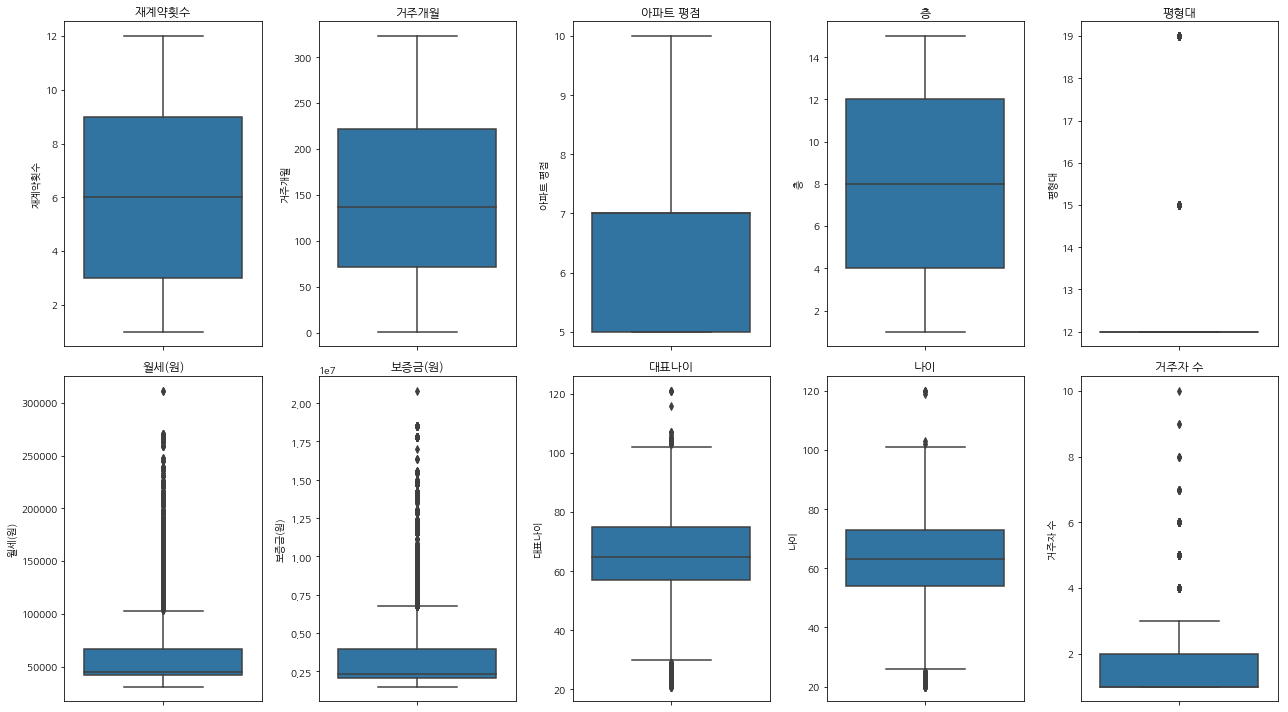

In [92]:
n_cols = d1.select_dtypes('number').columns

fig, ax = plt.subplots(2, 5, figsize=(18, 10))

for col, ax in zip(n_cols, ax.flatten()):
    sns.boxplot(y=d1[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

평형대, 월세, 보증금, 대표나이, 나이, 거주자 수에서 이상치 후보군이 식별된다.(iqr 기준)  
이 중 평형대, 월세, 보증금, 나이(대가족의 경우 10명까지 가능할 수도 있음)는 현실세계에 있을 수 있는 데이터이기 때문에  
이상치 처리하지 않으며, 나이의 경우 120세가 있을 수도 있지만 초고령자가 이렇게 많이 거주할 경우는 많지 않을 것이므로  
데이터 입력과정에서의 오류로 간주하여 상한값으로 치환해 준다.

In [97]:
d1['대표나이'] = d1['대표나이'].clip(upper=up['대표나이']) #lower
d1['나이'] = d1['나이'].clip(upper=up['나이'])

4.  **재계약 횟수의 중앙값을 기준으로 중앙값보다 크거나 같으면 '높음', 작으면 '낮음' 으로 하는 이분 변수를 구성하시오.**


In [100]:
cond = d1['재계약횟수'] >= d1['재계약횟수'].median()

d1['재계약수준'] = np.where(cond, "높음", "낮음")

d1['재계약수준'].value_counts()

높음    5388
낮음    4960
Name: 재계약수준, dtype: int64

5.  **차원축소의 필요성을 논하고, 필요에 따라 차원을 축소하고 불필요하다면 그 근거를 논하시오.**

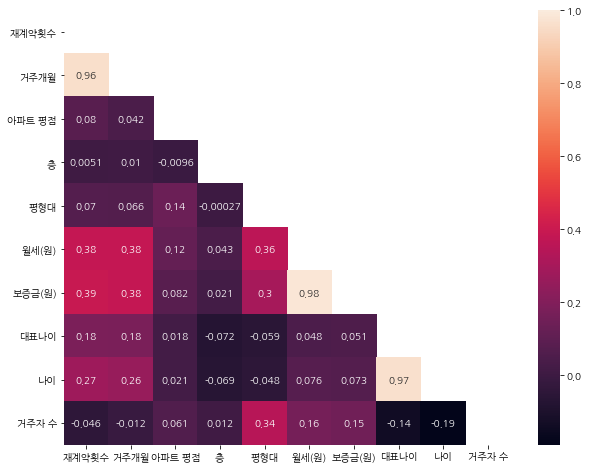

In [103]:
plt.figure(figsize=(10, 8))n_cols
corr = d1.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

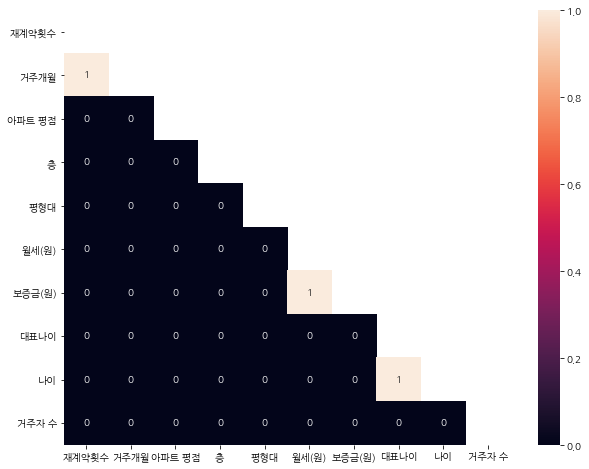

In [104]:
plt.figure(figsize=(10, 8))
corr = abs(d1.corr()) > 0.7
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

거주개월-재계약횟수, 보증금-월세, 나이-대표나이에서 비교적 강한 양의 선형 상관관계(피어슨)가 관찰된다.  
데이터의 내용을 보아도 비슷한 정보를 담고 있음을 알 수 있는데 이를 다중공선성이라고 하고,  
다중공선성이 있는 경우 모델 성능에 악영향을 끼치게 된다. vif도 확인한다. 

In [106]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = n_cols
vif['vif'] = [variance_inflation_factor(d1[n_cols].values, i) for i in range(len(n_cols))]
display(vif[1:])

,name,vif
1,거주개월,61.298507
2,아파트 평점,22.320930
3,층,4.187799
4,평형대,32.006376
5,월세(원),131.611244
6,보증금(원),90.975590
7,대표나이,417.135063
8,나이,399.590091
9,거주자 수,4.950039


vif 결과 10이상의 굉장히 높은 vif가 관찰된다. 월세는 131.61, 대표나이는 417.13에 달한다.  
이러한 다중공선성 제거를 위해 pca를 사용하여 다중공선성을 제거한다.   
(PCA를 통해 원 데이터의 분산설명력이 높은 주성분축을 재정렬한 후 적정한 수준의 주성분축을 선택하여 다중공선성 제거,   
주성분 축 간에는 직교하므로 vif가 1이 되어 다중공선성 제거)

,고윳값,분산설명력,누적분산설명력
0,176.058009,0.299540,0.299540
1,148.078674,0.211899,0.511439
2,116.170797,0.130418,0.641857
3,102.014493,0.100570,0.742427
4,100.263001,0.097146,0.839573
5,96.877235,0.090696,0.930269
6,79.986867,0.061827,0.992096
7,19.949232,0.003846,0.995942
8,17.021543,0.002800,0.998742
9,11.410568,0.001258,1.000000


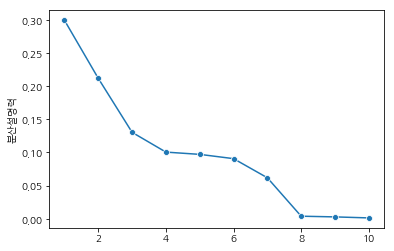

In [110]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#차원축소를 설명하기 위한 섹터로 전체데이터를 활용한다.
X = d1[n_cols]
sc = StandardScaler()
X = sc.fit_transform(X)
pca = PCA()

X = pca.fit_transform(X)

rs = pd.DataFrame({
    "고윳값": pca.singular_values_,
    "분산설명력": pca.explained_variance_ratio_, 
    "누적분산설명력": np.cumsum(pca.explained_variance_ratio_)
})

display(rs)

sns.lineplot(data=rs, x=rs.index+1, y='분산설명력', marker='o')
plt.show()

원 데이터의 피처를 사용하여 분산설명력이 높은 순서대로 새로운 주성분으로 변수가 생성되었다.  
5개의 주성분을 선택하면 전체 데이터의 약 84%의 분산을 설명할 수 있으며, 다중공선성 또한 제거된다.

In [121]:
pca = PCA(n_components=5)
X = pca.fit_transform(X)
vif = pd.DataFrame()
vif['name'] = np.arange(1, 6)
vif['vif'] = [variance_inflation_factor(X, i) for i in range(0, 5)]
display(vif)

,name,vif
0,1,1.0
1,2,1.0
2,3,1.0
3,4,1.0
4,5,1.0


6.  **재계약 횟수 이분 변수를 활용하여 세그먼트를 구분하고 각 세그먼트의 특징을 분석하시오.**

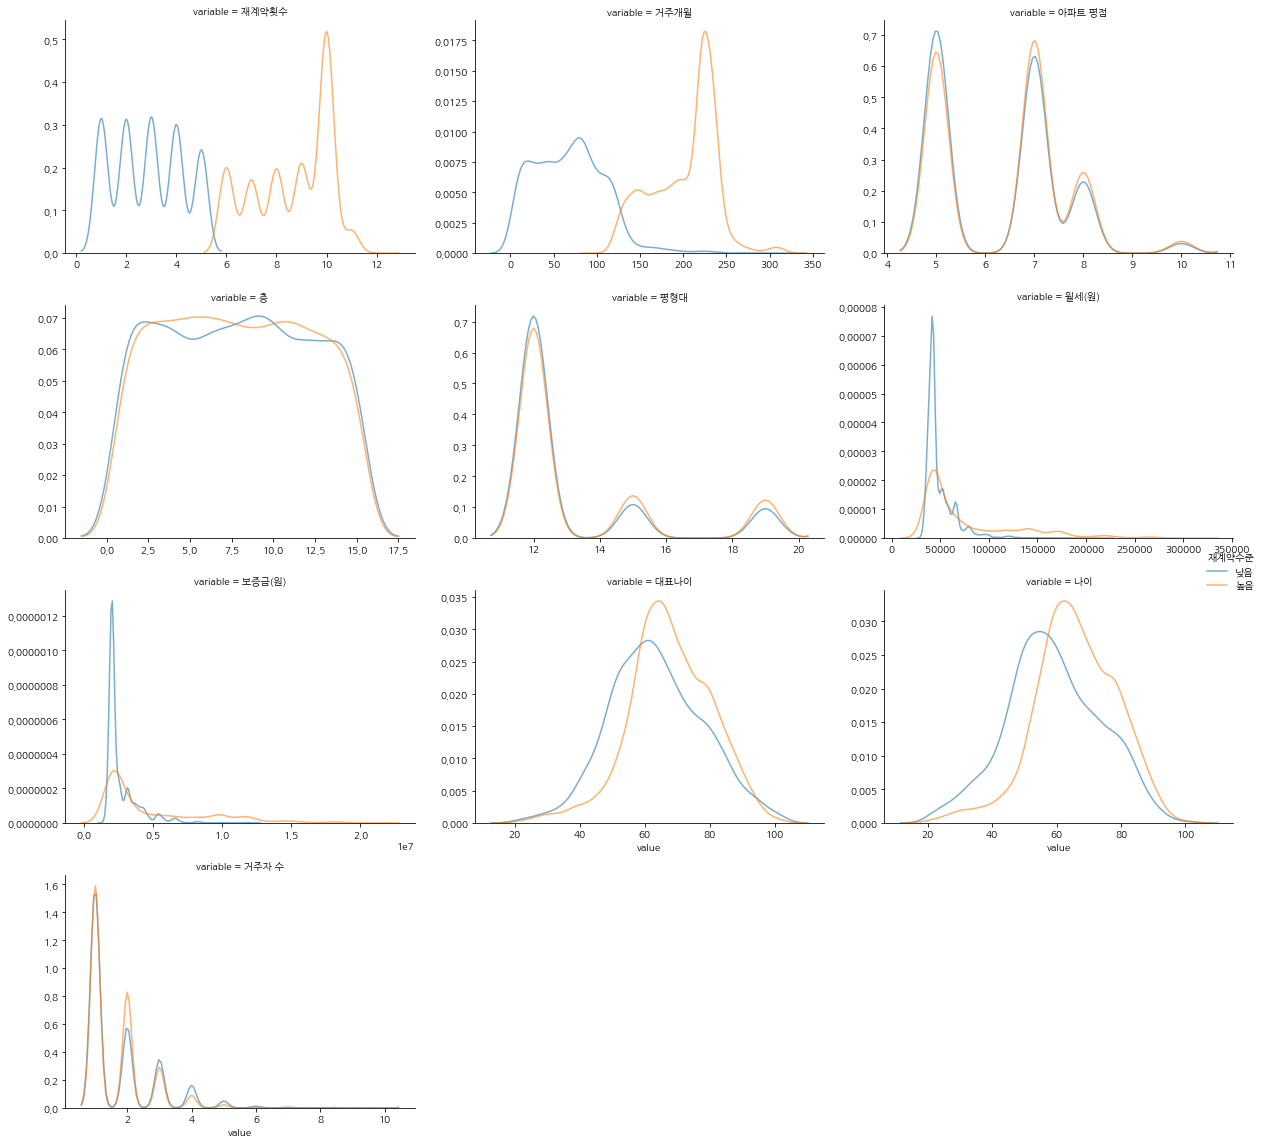

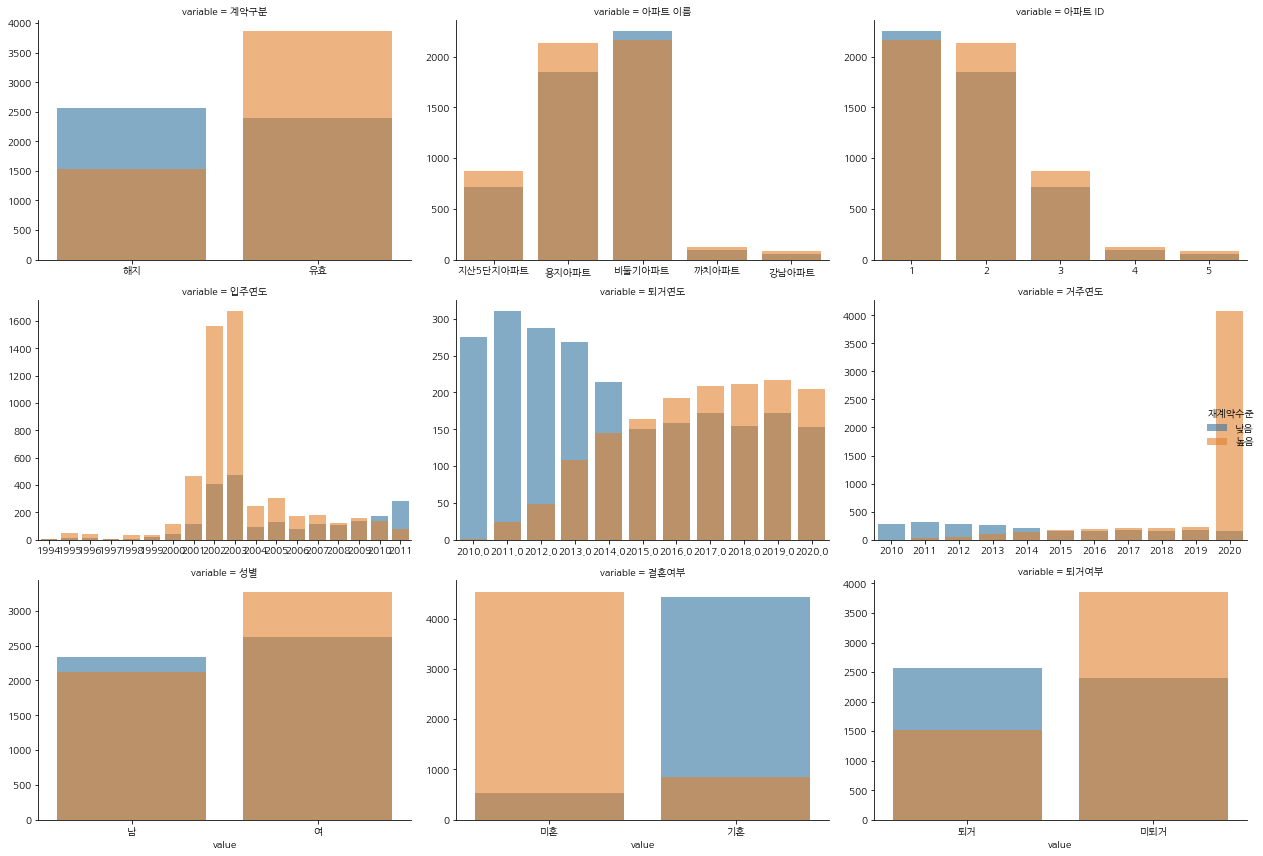

In [149]:
n_cols = d1.select_dtypes('number').columns
c_cols = d1.select_dtypes('O').columns[:-1]

mt = d1.melt(id_vars='재계약수준', value_vars=n_cols)
g = sns.FacetGrid(mt, col='variable', hue='재계약수준', col_wrap=3, aspect=1.4, height=4, sharex=False, sharey=False)
g.map(sns.kdeplot, 'value', alpha=0.6)
g.add_legend()
plt.tight_layout()
plt.show()

mt = d1.melt(id_vars=['재계약수준'], value_vars=c_cols)
g = sns.FacetGrid(mt, col='variable', hue='재계약수준', col_wrap=3, aspect=1.4, height=4, sharex=False, sharey=False)
g.map(sns.countplot, 'value', alpha=0.6)
g.add_legend()
plt.tight_layout()
plt.show()

1. 재계약 수준 낮음
    - 재계약 횟수가 0~6 사이로 낮음
    - 거주개월이 0~150 사이로 비교적 짧음
    - 월세가 50000원으로 낮은 구간에 집중됨
    - 보증금이 낮은 구간에 집중됨
    - 대표나이는 높음 수준에 비해 낮은 편
    - 나이도 높음 수준에 비해 낮음 편
    - 비둘기 아파트에 가장 많은 비율 거주
    - 높음에 비해 최근(2011)에 입주한 비율이 높음
    - 성별은 높음에 비해 남성 비율이 높음
    - 기혼 비율이 높음



2. 재계약 수준 높음
    - 재계약 횟수가 5~12 사이로 높음
    - 거주개월이 비교적 높은 편
    - 월세가 낮음에 비해 비교적 넓게 분포(첨도가 낮음)
    - 보증금이 낮음에 비해 비교적 넓게 분포(첨도 낮음)
    - 대표나이는 높음 수준에 비해 낮은 편
    - 나이도 높음 수준에 비해 높은 편
    - 비둘기 아파트에 가장 많은 비율 거주
    - 높음에 비해 과거 입주(2000년대) 인원비율이 높음
    - 성별은 여성 비율이 높음
    - 미혼 비율이 높음

8.  **최종 채택한 모델에서 각각 유의하게 작용하는 변수를 확인하고 설명하시오.**

In [169]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


#데이터 분할
x = d1.drop(columns=['재계약수준', '아파트 이름', '재계약횟수', '퇴거연도'])
y = d1['재계약수준']

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42)

n_cols = train_x.select_dtypes('number').columns
c_cols = train_x.select_dtypes('O').columns

processor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.85))]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

rf = Pipeline([
    ('processor', processor), 
    ('cl', RandomForestClassifier(random_state=42))
])

rf.fit(train_x, train_y)

dt_list = [('train', train_x, train_y), ('test', test_x, test_y)]

for d_name, x, y in dt_list:
    pred = rf.predict(x)
    acc = accuracy_score(y, pred)
    print(f"{d_name} 데이터 학습결과: ")
    print(f"- 정확도(acc): {acc}")
    print(classification_report(y, pred))

train 데이터 학습결과: 
- 정확도(acc): 1.0
              precision    recall  f1-score   support

          낮음       1.00      1.00      1.00      3745
          높음       1.00      1.00      1.00      4016

    accuracy                           1.00      7761
   macro avg       1.00      1.00      1.00      7761
weighted avg       1.00      1.00      1.00      7761

test 데이터 학습결과: 
- 정확도(acc): 0.9543873212214921
              precision    recall  f1-score   support

          낮음       0.95      0.95      0.95      1215
          높음       0.96      0.96      0.96      1372

    accuracy                           0.95      2587
   macro avg       0.95      0.95      0.95      2587
weighted avg       0.95      0.95      0.95      2587



모델 학습 결과, 과적합 없이 두 클래스의 분류를 잘 해냄을 알 수 있다. 

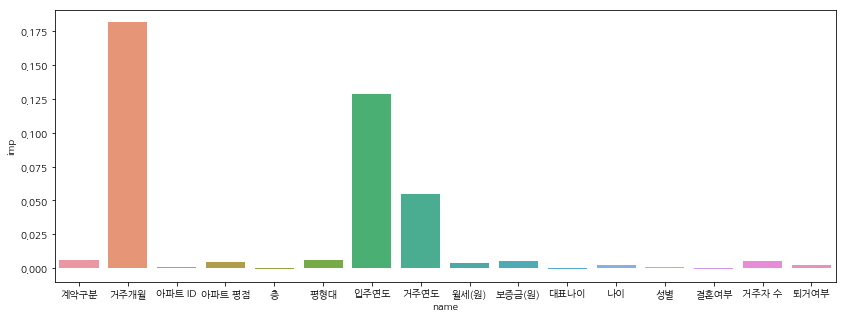

In [196]:
# permutation imp

from sklearn.inspection import permutation_importance

f_imp = permutation_importance(rf, test_x, test_y, n_repeats=10, random_state=42)
feat = train_x.columns

f_mean = f_imp.importances_mean
f_imp_df = pd.DataFrame({'name': feat, 'imp': f_mean})

plt.figure(figsize=(14, 5))
sns.barplot(data=f_imp_df, x='name', y='imp')

plt.show()

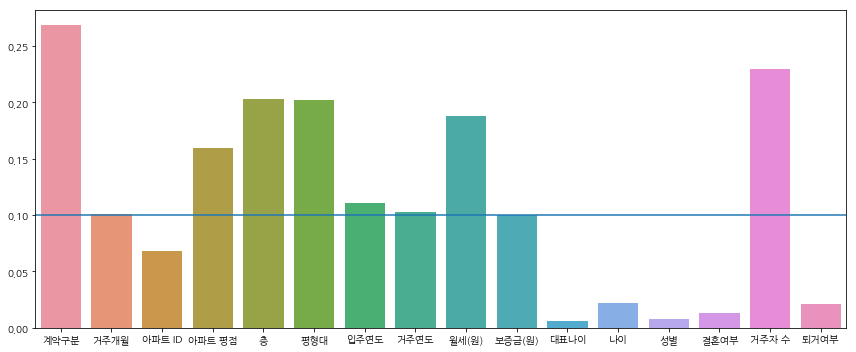

In [183]:
import re

#pca 주성분 중요도
n_pc = rf.named_steps['processor'].transformers_[0][1]['pca'].n_components_
pc_imp = rf.named_steps['cl'].feature_importances_[:n_pc]

comp = rf.named_steps['processor'].transformers_[0][1]['pca'].components_

num_imp = np.abs(comp.T) @ pc_imp

# 원핫인코딩 범주형 중요도
oh = rf.named_steps['processor'].transformers_[1][1]['onehot']
oh_feat = oh.get_feature_names(c_cols)
oh_imp = rf.named_steps['cl'].feature_importances_[n_pc:]

cat_orig = [re.sub(r'(_[^_]+)$', '', name) for name in oh_feat]

cat_df = pd.DataFrame({
    'origin_var': cat_orig, 
    'imp': oh_imp
})

cat_imp_sum = cat_df.groupby('origin_var')['imp'].sum()

feat_names = x.columns
imp = np.concatenate([num_imp, cat_imp_sum])

plt.figure(figsize=(12, 5))
sns.barplot(x=feat_names, y=imp)
plt.tight_layout()
plt.axhline(y=0.1)
plt.show()


랜덤포레스트 학습결과이다. 계약구분, 거주자수가 모델학습에 중요한 영향을 끼친 것을 확인할 수 있다.  
그 밖의 아파트 평점, 층, 평형대, 월세도 0.1 이상의 중요도를 가지고 있다.

9.  **해당 데이터 분석결과로 얻을 수 있는 점을 제시하시오.**

계약구분(계약, 해지), 거주자 수 피처가 분류를 잘 잡아낼 수 있는 특징을 가지고 있으며, 월세, 층, 평형대, 아파트 평점 또한  
분류성능의 중요한 영향을 끼지는 feature라고 할 수 있다.

월세가 높은 경우, 낮은 평형대, 고층, 높은 보증금의 경우 재계약 수준이 높으며, 다음에도 재계약할 가능성이 있다고 할 수 있다.  
따라서 월세를 너무 싸게 하지 않고, 적정 수준으로 편성한다면 좋을 것이다.

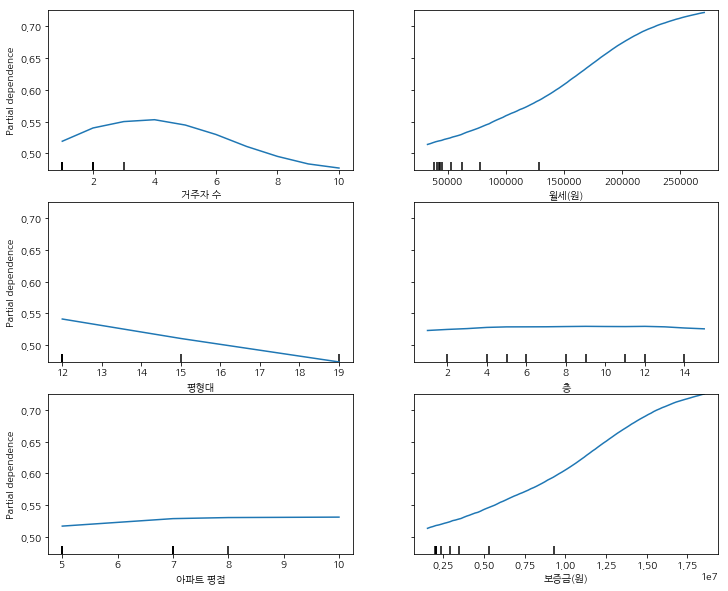

In [195]:
from sklearn.inspection import partial_dependence, plot_partial_dependence

s_cols = ['거주자 수', '월세(원)', '평형대', '층', '아파트 평점', '보증금(원)']

fig, ax = plt.subplots(3, 2, figsize=(12, 10))

plot_partial_dependence(estimator = rf, 
                       X=test_x, 
                       features=s_cols, 
                       percentiles=(0, 1), 
                       ax=ax)
plt.show()

## 문제 2

**Data description**

경기 당 9이닝 동안 1번 타자, 2번 타자의 출루 정보를 기록한 데이터입니다.

**수치 상세 내용**

-   **1: 1루타**

-   **2: 2루타**

-   **3: 3루타**

-   **4: 홈런**

-   **5: 삼진 제외 모든 아웃**

-   **6: 볼넷**

-   **7: 삼진**

-   **8: 몸에 맞는 공**

-   **9: 희생 번트**

**타자 행동**

| 컬럼명   | 의미 (회 == 이닝)  |
|----------|--------------------|
| **a1_1** | 1회 첫 타자 행동   |
| **a1_2** | 1회 둘째 타자 행동 |
| **a2_1** | 2회 첫 타자 행동   |
| **a2_2** | 2회 둘째 타자 행동 |
| **a3_1** | 3회 첫 타자 행동   |
| **a3_2** | 3회 둘째 타자 행동 |
| **a4_1** | 4회 첫 타자 행동   |
| **a4_2** | 4회 둘째 타자 행동 |
| **a5_1** | 5회 첫 타자 행동   |
| **a5_2** | 5회 둘째 타자 행동 |
| **a6_1** | 6회 첫 타자 행동   |
| **a6_2** | 6회 둘째 타자 행동 |
| **a7_1** | 7회 첫 타자 행동   |
| **a7_2** | 7회 둘째 타자 행동 |
| **a8_1** | 8회 첫 타자 행동   |
| **a8_2** | 8회 둘째 타자 행동 |
| **a9_1** | 9회 첫 타자 행동   |
| **a9_2** | 9회 둘째 타자 행동 |

#### **득점**

| 컬럼명 | 의미 (회 == 이닝) |
|--------|-------------------|
| **b1** | 1회 총 득점수     |
| **b2** | 2회 총 득점수     |
| **b3** | 3회 총 득점수     |
| **b4** | 4회 총 득점수     |
| **b5** | 5회 총 득점수     |
| **b6** | 6회 총 득점수     |
| **b7** | 7회 총 득점수     |
| **b8** | 8회 총 득점수     |
| **b9** | 9회 총 득점수     |

In [263]:
d2 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/29/problem2.csv')

In [264]:
d2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 28 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   game_id  200 non-null    int64  
 1   a1_1     188 non-null    float64
 2   a1_2     200 non-null    int64  
 3   a2_1     200 non-null    object 
 4   a2_2     200 non-null    int64  
 5   a3_1     200 non-null    int64  
 6   a3_2     200 non-null    int64  
 7   a4_1     200 non-null    object 
 8   a4_2     200 non-null    int64  
 9   a5_1     200 non-null    int64  
 10  a5_2     200 non-null    int64  
 11  a6_1     200 non-null    int64  
 12  a6_2     200 non-null    int64  
 13  a7_1     200 non-null    object 
 14  a7_2     200 non-null    int64  
 15  a8_1     200 non-null    int64  
 16  a8_2     200 non-null    int64  
 17  a9_1     200 non-null    int64  
 18  a9_2     200 non-null    int64  
 19  b1       200 non-null    int64  
 20  b2       200 non-null    int64  
 21  b3       200 non

In [265]:
d2.isna().sum()

game_id     0
a1_1       12
a1_2        0
a2_1        0
a2_2        0
a3_1        0
a3_2        0
a4_1        0
a4_2        0
a5_1        0
a5_2        0
a6_1        0
a6_2        0
a7_1        0
a7_2        0
a8_1        0
a8_2        0
a9_1        0
a9_2        0
b1          0
b2          0
b3          0
b4          0
b5          0
b6          0
b7          0
b8          0
b9          0
dtype: int64

In [266]:
d2.head()

,game_id,a1_1,a1_2,a2_1,a2_2,a3_1,a3_2,a4_1,a4_2,a5_1,...,a9_2,b1,b2,b3,b4,b5,b6,b7,b8,b9
0,201900016,5.0,5,5,5,5,5,5,5,5,...,5,0,0,0,0,0,0,0,4,2
1,201900023,6.0,4,5,5,2,5,1,1,6,...,7,3,0,0,1,0,1,3,1,0
2,201900103,5.0,6,5,5,1,9,5,4,6,...,6,0,0,1,1,4,1,2,0,1
3,201900112,5.0,7,6,1,5,5,1,5,1,...,5,0,3,0,0,0,0,1,0,0
4,201900131,5.0,1,2,5,2,5,7,2,6,...,6,0,2,4,1,2,2,0,1,0


In [267]:
i_cols = d2.select_dtypes('O').columns

d2[i_cols].value_counts()

a2_1  a4_1  a7_1
5     5     5       13
7     5     5        9
5     7     7        6
1     5     5        6
5     1     5        6
                    ..
            "        1
      &     5        1
            2        1
4     7     5        1
:     7     5        1
Length: 99, dtype: int64

문자 데이터가 섞여있다. 데이터 입력 과정의 실수로 판단되므로 삭제한다. 

In [268]:
#우선 데이터 결측치 처리를 한다. 
#a1_1~ a9_2까지는 이산형 데이터이나 object로 되었다는 것은 이상값이 있다는 의미
#또한 a1_1에 12개의 결측치가 존재한다.(전체의 약 5%)
#일단 수집데이터이므로 적절한 값으로 보간하기 적절치 않으므로 삭제
print(f"삭제 전 데이터 갯수: {len(d2)}")
for col in i_cols:
    d2[col] = pd.to_numeric(d2[col], errors='coerce')
#결측치 삭제는 마지막에 한번만 한다.
d2 = d2.dropna()
print(f"삭제 후 데이터 갯수: {len(d2)}")

삭제 전 데이터 갯수: 200
삭제 후 데이터 갯수: 180


In [269]:
d2[i_cols].value_counts()

a2_1  a4_1  a7_1
5.0   5.0   5.0     12
7.0   5.0   5.0      7
5.0   7.0   7.0      6
      1.0   5.0      6
1.0   5.0   5.0      6
                    ..
5.0   4.0   6.0      1
      3.0   7.0      1
      1.0   2.0      1
4.0   7.0   5.0      1
1.0   1.0   1.0      1
Length: 87, dtype: int64

1.  **각 회차별로 1번 타자의 출루 (1,2,3루타와 사사구(볼넷, 몸에맞는공))가 있는 경우에 대해 득점이 발생 했는지 확인하고자 한다. 이를 위한 전처리를 수행하시오. (단, 첫 번째 혹은 두 번째 타자가 홈런을 친 경우 해당 회차 데이터 제외)**

In [276]:
c1 = [f for f in d2.columns if '_1' in f]
c2 = [f for f in d2.columns if '_2' in f]
b = [f for f in d2.columns if 'b' in f]


#첫번째 타자 데이터
mt1 = d2.melt(id_vars='game_id', 
             value_vars=c1, 
             var_name='회차', 
             value_name='action1')

mt1['회차'] = mt1['회차'].str[1:2]

mt1

#두번째 타자 데이터
mt2 = d2.melt(id_vars='game_id', 
             value_vars=c2, 
             var_name='회차', 
             value_name='action2')

mt2['회차'] = mt2['회차'].str[1:2]

#득점정보
mt3 = d2.melt(id_vars='game_id', 
             value_vars=b, 
             var_name='회차', 
             value_name='score')

mt3['회차'] = mt3['회차'].str.replace('b', '')


df = pd.merge(mt1, mt2, on=['game_id', '회차'], how='inner', sort=['game_id', '회차'])
df = pd.merge(df, mt3, on=['game_id', '회차'], how='inner', sort=['game_id', '회차'])


print(len(df))
#첫 번째 혹은 두 번째 타자가 홈런을 친 경우 해당 회차 데이터 제외
df = df[~((df['action1'] == 4) | (df['action2'] == 4))]

#1번 타자의 출루 (1,2,3루타와 사사구(볼넷, 몸에맞는공))가 있는 경우에 대해서만 남김
df = df[df['action1'].isin([1, 2, 3, 6, 8])]
display(df)
print(f"최종 데이터 수: {len(df)}")

1620


,game_id,회차,action1,action2,score
7,201900016,8,1.0,1,4
8,201900016,9,1.0,5,2
11,201900023,3,2.0,5,0
12,201900023,4,1.0,1,1
13,201900023,5,6.0,5,0
...,...,...,...,...,...
1604,201902392,3,1.0,5,2
1605,201902392,4,6.0,5,1
1608,201902392,7,2.0,1,0
1615,201902394,5,6.0,7,0


최종 데이터 수: 480


In [277]:
# 득점여부
df['is_score'] = np.where(df['score']>0, 1, 0)

2.  **Logistic Regression을 적용하고 2번타자의 희생번트 여부에 대한 회귀 계수 검정을 실시하시오.**

In [282]:
import statsmodels.formula.api as smf

model = smf.logit('is_score ~ C(action1) + C(action2)', data=df).fit()

print(model.summary())

         Current function value: 0.602946
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:               is_score   No. Observations:                  480
Model:                          Logit   Df Residuals:                      468
Method:                           MLE   Df Model:                           11
Date:                Fri, 26 Sep 2025   Pseudo R-squ.:                  0.1202
Time:                        00:19:07   Log-Likelihood:                -289.41
converged:                      False   LL-Null:                       -328.95
Covariance Type:            nonrobust   LLR p-value:                 2.229e-12
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.2245      0.309      3.958      0.000       0.618       1.831
C(action1)[T.2.0]     0.4272      0.257     

모델의 우도비 검정 pvalue 가 2.229e-12로 유의수준 5% 하에서 통계적으로 유의하므로  
모델은 통계적으로 유의하다.(적어도 하나의 회귀계수는 0이 아니다.)  

2번 타자의 희생번트(C(action2)[T.9])의 pvalue를 확인해보면 0.163로 통계적으로 유의하지 않다는 것을 확인할 수 있다. 


3.  **SMOTE (random_state =0 지정)를 적용하여 data imbalance를 해결하시오.**


In [396]:
# 종속변수는 불균형이 아님
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter

x = df[['action1', 'action2']]
y = df['is_score']

x[['action1', 'action2']] = x[['action1', 'action2']].astype('O')

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=0)

sm = SMOTE(random_state=0)
train_x, train_y = sm.fit_resample(train_x, train_y)

print(Counter(train_y))

Counter({1: 204, 0: 204})


4.  **Logistic Regression을 적용하고 결과를 분석하시오.**

In [397]:
train2 = np.c_[train_x, train_y]
train2 = pd.DataFrame(train2, columns=['action1', 'action2','is_score'])

test2 = np.c_[test_x, test_y]
test2 = pd.DataFrame(test2, columns=['action1', 'action2', 'is_score'])

model = smf.logit('is_score ~ C(action1) + C(action2)', data=train2).fit()

print(model.summary())

         Current function value: 0.597641
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:               is_score   No. Observations:                  408
Model:                          Logit   Df Residuals:                      390
Method:                           MLE   Df Model:                           17
Date:                Fri, 26 Sep 2025   Pseudo R-squ.:                  0.1378
Time:                        01:22:23   Log-Likelihood:                -243.84
converged:                      False   LL-Null:                       -282.80
Covariance Type:            nonrobust   LLR p-value:                 8.910e-10
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.9386      0.324      2.899      0.004       0.304       1.573

In [398]:
(np.exp(model.params)-1)

Intercept                           1.556364e+00
C(action1)[T.2.0]                   1.161917e+00
C(action1)[T.2.5856314117736314]   -1.000000e+00
C(action1)[T.3.0]                   4.198536e+00
C(action1)[T.6.0]                   4.218855e-01
C(action1)[T.6.73145188408533]     -1.000000e+00
C(action1)[T.7.97285672877578]     -1.000000e+00
C(action1)[T.8.0]                   1.672830e-01
C(action2)[T.2.0]                   3.190238e+00
C(action2)[T.2.9724230233796423]   -1.000000e+00
C(action2)[T.3.0]                   2.893494e+07
C(action2)[T.5.0]                  -7.936847e-01
C(action2)[T.5.325247677740979]    -1.000000e+00
C(action2)[T.5.613511018874138]    -1.000000e+00
C(action2)[T.6.0]                  -2.613913e-01
C(action2)[T.7.0]                  -8.849945e-01
C(action2)[T.8.0]                  -7.768867e-01
C(action2)[T.9.0]                  -5.947360e-01
dtype: float64

In [399]:
-5.947360e-01

-0.594736

일단 데이터 증강 이후 2번 타자의 희생번트 회귀계수가 0.026으로 통계적으로 유의하게 되었다.  
오즈비 해석을 하자면 2번 타자의 1루타일 일 때 비해 희생번트일 경우 득점할 오즈가 약 59.47% 낮다고 할 수 있다. 

In [400]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

rs = pd.DataFrame(columns=['모델', '데이터', 'recall', 'precision', 'f1', 'roc_auc'])

for i, dt in enumerate([train2, test2]):
    proba1 = model.predict(dt)
    pred1 = np.where(proba1 > 0.5, 1, 0)
    recall = recall_score(dt['is_score'].astype('int'), pred1)
    pr = precision_score(dt['is_score'].astype('int'), pred1)
    f1 = f1_score(dt['is_score'].astype('int'), pred1)
    roc = roc_auc_score(dt['is_score'].astype('int'), proba1)
    rs.loc[len(rs)] = ['로지스틱 회귀', i, recall, pr, f1, roc]
display(rs)

,모델,데이터,recall,precision,f1,roc_auc
0,로지스틱 회귀,0,0.647059,0.676923,0.661654,0.729131
1,로지스틱 회귀,1,0.727273,0.761905,0.744186,0.727694


5.  **XGBoost 적용하고 결과를 분석하시오.**

In [402]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=0)
xgb.fit(train_x, train_y)

dt_list = [('train', train_x, train_y), ('test', test_x.values, test_y.values)]

for d_name, x, y in dt_list:
    pred2 = xgb.predict(x)
    proba2 = xgb.predict_proba(x)
    recall = recall_score(y, pred2)
    pr = precision_score(y, pred2)
    f1 = f1_score(y, pred2)
    roc = roc_auc_score(y, pred2)
    rs.loc[len(rs)] = ['xgboost', d_name, recall, pr, f1, roc]
    
display(rs)

,모델,데이터,recall,precision,f1,roc_auc
0,로지스틱 회귀,0,0.647059,0.676923,0.661654,0.729131
1,로지스틱 회귀,1,0.727273,0.761905,0.744186,0.727694
2,xgboost,train,0.568627,0.734177,0.640884,0.681373
3,xgboost,test,0.560606,0.711538,0.627119,0.641414


두 모델의 test 성능을 비교하였을 때 로지스틱 회귀의 성능이 전반적으로 좋은 것을 확인할 수 있다.  
xgboost는 부스팅 기반 트리 앙상블 모델로 불균형에 강건한 특성을 가지고 있어, 오버샘플링이 오히려 성능을 저하시켰다고  
예상된다. 


## 문제 3

별도의 데이터 없음

**제품 A의 불량률은 0.03이다. 25개의 제품을 뽑았을 때 3개가 불량일 확률을 구하시오(소수점 다섯 째 자리에서 반올림).**

이항 분포의 확률 질량 함수는 다음과 같습니다.

$P(X = k) = \binom{n}{k} p^k (1 - p)^{n - k}$

-   n : 시도 횟수

-   k : 성공 횟수

-   p : 불량 확률

이항 분포의 확률 질량 함수에 각 파라미터를 대입하여 결과를 산출합니다.

$P(X = 3) = \binom{25}{3} 0.03^k (1 - 0.03)^{25 - 3} = 0.03177$

파이썬으로 계산한 결과는 다음과 같습니다.

In [4]:
from scipy.stats import binom

p = 0.03 # 불량률
k = 3 # 불량갯수
n = 25 #제품수

pv = binom.pmf(k, n, p)

print(f"이항분포 3개가 불량일 확률: {pv:.4f}")

이항분포 3개가 불량일 확률: 0.0318


3개가 불량일 확률은 0.0318이다.  

## 문제 4

별도의 데이터 없음

**C사 생산 제품 1000개 중 양품이 600개, D사 생산 제품 500개 중 양품이 200개 이다. 두 회사의 양품률에 차이가 있는지 검정하시오.**


두 모집단의 모비율에 대한 검정이므로 z 검정을 실시한다. 유의수준 5% 하에서 다음과 같은 가설을 세워 검정한다.  

- 귀무가설: 두 모집단의 모비율 차는 0이다. 
- 대립가설: 두 모집단의 모비율 차는 0이 아니다. 

양측검정을 수행한다. 

In [12]:
from scipy.stats import norm

n1, n2 = 1000, 500 #갯수
p1, p2 = 600/n1, 200/n2 #확률
a = 0.05 #유의수준

diff = p1 - p2 #모비율차
d0 = 0 #모비율 차 가정

pp = (n1*p1 + n2*p2) / (n1+n2) #합동표본비율
se = np.sqrt(pp*(1-pp)*(1/n1+1/n2))
stat = (p1-p2-d0)/se #통계량
p_value = (1-norm.cdf(np.abs(stat)))*2 #양측검정

print(f"z 검정 통계량: {stat:.3f}")
print(f"pvalue: {p_value}")

z 검정 통계량: 7.319
pvalue: 2.4935609133081016e-13


유의수준 5%에서 p-value가 매우 작으므로 귀무가설을 기각, 따라서 두 회사 불량률은 유의미한 차이가 존재하는 것이 통계적으로 유의함



## 문제 5

**Data description**

-   **name** : 차종(A, B, C, D)

-   **ratio** : 5회 실험 시 범퍼 파손 정도

In [14]:
d5 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/29/problem5.csv')

In [15]:
d5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    20 non-null     object 
 1   ratio   20 non-null     float64
dtypes: float64(1), object(1)
memory usage: 448.0+ bytes


In [16]:
d5.head()

,name,ratio
0,A,10.993428
1,A,9.723471
2,A,11.295377
3,A,13.046060
4,A,9.531693


1.  **각 차종 별 범퍼 파손의 정도에 차이가 유의한지 검정하시오(모분산 동일, 정규성 가정 하에).**

정규성, 등분산성이 가정되어 있기 때문에(독립성은 수집데이터이므로 만족한 것로 간주) 모수검정을 시행할 수 있다.  
종속변수는 연속형 변수이며, 4개의 범주형 변수가 설명변수이므로 one-way anova 검정을 수행한다. 

유의수준 5% 하에서 검정을 수행한다.  

- 귀무가설: 각 차종별 범퍼 파손 정도는 차이가 없다. 
- 대립가설: 적어도 하나의 차종별 범퍼 파손정도는 차이가 있다.

In [20]:
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf

model = smf.ols('ratio~C(name)', data=d5).fit()
anv = anova_lm(model, typ=2)
display(anv)

,sum_sq,df,F,PR(>F)
C(name),236.534027,3.0,24.976953,0.000003
Residual,50.507154,16.0,NaN,NaN


one-way anova 검정결과이다. F통계량이 0.000003로 0.05보다 작으므로 귀무가설을 기각한다.   
따라서 적어도 하나의 차종별 범퍼 파손정도는 차이가 있다.는 통계적으로 유의하다. 

2.  **귀무가설을 채택한다면 그 의미를 해석하고, 귀무가설을 기각한다면 사후분석을 수행하시오.**


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B   5.3934  0.001   2.1785  8.6083   True
     A      C  -4.2156 0.0085  -7.4305 -1.0007   True
     A      D  -0.7086 0.9207  -3.9235  2.5063  False
     B      C   -9.609    0.0 -12.8239 -6.3941   True
     B      D   -6.102 0.0003  -9.3169 -2.8871   True
     C      D    3.507 0.0302   0.2921  6.7219   True
-----------------------------------------------------


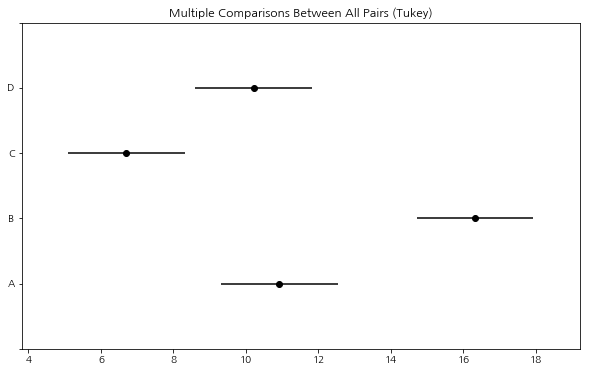

In [24]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

rs = pairwise_tukeyhsd(endog=d5['ratio'], groups=d5['name'], alpha=0.05)

print(rs)

rs.plot_simultaneous()
plt.show()

A-D 쌍을 제외하고는 범퍼 파손정도의 차이가 있다고 할 수 있다.  
(A-D) 쌍 p-value가 0.9207이므로 귀무가설을 기각하지 못한다.  
도표를 통해서도 차이여부를 확인할 수 있다.   
중앙값 기준 B사의 범퍼파손정도가 가장 크며, C사가 가장 적으므로 다양한 요소를 고려했을 때 차이가 없다면 C사의 제품을  
구매하는 것이 합리적이다. 


## 문제 6

별도의 데이터 없음

**L1,L2,L3 세 개의 생산라인에서 각각 13%, 37%, 50%를 생산하며, 각각 1.1% , 2.1%, 3.3% 불량률을 갖는다. 불량 제품이 나왔을 때 L1 라인에서 생산되었을 확률을 구하시오(소수점 둘째자리에서 반올림).**

베이즈 정리를 활용한 문제이다. 사전확률을 사용하여 사후확률을 도출한다. 

In [26]:
#생산확률
p1 = 0.13 
p2 = 0.37
p3 = 0.5

#각각 생산라인의 불량률
e1 = 0.011
e2 = 0.021
e3 = 0.033

#전체 불량률 
t_e = (p1*e1)+(p2*e2)+(p3*e3)

# 불량 제품이 나왔을 때 L1 라인에서 생산되었을 확률
#P(L1라인에서 생산되었을 확률|불량제품확률) =  P(불량제품확률|P L1 생산확률)*p(L1 생산확률) / P(불량제품확률)
ans = (e1*p1)/t_e

print(f"{ans:.1f}")

0.1
